In [3]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../")
from epd_process_funcs import *

from visualisation import *

In [7]:
# solar=pd.read_csv('4) Data/BOM_NCI/2023/NCI_processed_Adelaide_grouped.csv')
solar = pd.read_csv("/home/hossein/CICCADA/BOM_NCI/2023/NCI_processed_grouped_all.csv")
solar["time"] = pd.to_datetime(solar["time"])
solar["time"] = solar["time"].dt.tz_localize("utc")
solar["time"] = solar["time"].dt.tz_convert(pytz.FixedOffset(9.5 * 60))
solar["postcode"] = solar["postcode"].astype(int)
solar.rename(columns={"surface_global_irradiance": "GHI"}, inplace=True)
solar_bk = solar.copy()

In [8]:
edp_path = "4) Data/EDP SA 2023 Data"
edp_files = glob(edp_path + "/SA_site_edp_2023_S*.csv")
df = pd.concat(
    [pd.read_csv(i) for i in edp_files if os.path.getsize(i) > 0]
).reset_index(drop=True)

In [271]:
import duckdb

db = duckdb.query(f"""
    SELECT distinct edp_site_id, count(*) as num_rows, max(datetime) as max_t
    FROM '{edp_path}/SA_site_edp*.csv' 
    group by edp_site_id 
    order by num_rows desc
    \
""").to_df()
db["max_t"] = pd.to_datetime(db["max_t"]).dt.tz_localize(pytz.FixedOffset(9.5 * 60))
db

,edp_site_id,num_rows,max_t
0,S0343,630648,2023-12-31 23:55:00+09:30
1,S0357,630636,2023-12-31 23:55:00+09:30
2,S0331,630558,2023-12-31 23:55:00+09:30
3,S0183,630456,2023-12-31 23:55:00+09:30
4,S0440,630354,2023-12-31 23:55:00+09:30
...,...,...,...
73,S0296,198998,2023-12-12 14:55:00+09:30
74,S0475,182832,2023-12-31 23:55:00+09:30
75,S0204,153786,2023-09-25 00:05:00+09:30
76,S0207,120304,2023-07-29 07:45:00+09:30


In [11]:
meta_data2

,edp_site_id,postcode,Srated
0,S0023,5323,4.00
1,S0026,5048,3.00
2,S0029,5025,5.00
3,S0030,5049,9.20
4,S0031,5127,9.00
...,...,...,...
144,W0273,5062,0.00
145,W0314,5011,8.50
146,W0325,5120,0.00
147,W0331,5093,4.95


In [9]:
meta_data1 = pd.read_csv(edp_path + "/edp_sites_metadata_sa_postcode.csv")
meta_data2 = pd.read_csv(edp_path + "/edp_sites_metadata59239829.csv")
meta_data2 = meta_data2[meta_data2["state"] == "SA"]
meta_data3 = meta_data2.merge(
    meta_data1[["edp_site_id", "postcode"]], on="edp_site_id", how="left"
)
meta_data3["Srated"] = (
    meta_data3["inverter_ac_rating_kw"] * meta_data3["inverter_count"]
)
meta_data3["Srated"] = meta_data3.apply(
    lambda row: (
        row["inverter_ac_rating_kw"]
        if pd.isna(row["inverter_count"])
        else row["Srated"]
    ),
    axis=1,
)
meta_data2 = (
    meta_data3.groupby(["edp_site_id", "postcode"]).agg({"Srated": "sum"}).reset_index()
)
# meta_data.head()[:2]
# df[:2]

In [5]:
df7 = df.query(f"circuit_label=='pv_site_net'")
df7 = df7.sort_values(by=["edp_site_id", "datetime"]).reset_index(drop=True)
df7 = df7.drop_duplicates(
    subset=["edp_site_id", "edp_circuit_label"], keep="first"
).reset_index(drop=True)
df7_counts = (
    df7.groupby("edp_site_id")
    .count()
    .reset_index()[["edp_site_id", "edp_device_and_circuit"]]
)
df7_counts = df7_counts.rename(columns={"edp_device_and_circuit": "count_circuits"})
df7 = df7.merge(df7_counts, on="edp_site_id", how="left")
df7.drop(
    columns=["voltage_max", "voltage_min", "current_min", "current_max"], inplace=True
)
df7 = df7.query(f"count_circuits > 1")
# df7 = df7.query(f"count_circuits ==2")
# df7 = df7.query(f"edp_site_id=='S0343'")

In [77]:
# df7.merge(meta_data2, on='edp_site_id', how='left').drop(columns=['unix_time', 'state','limit_enabled','has_battery','monitoring_hardware','islandable','limit_amount','limit_applied','site_timezone','last_date_metadata_received','battery_size_make_model','datetime','edp_device_and_circuit','circuit_label','first_date_metadata_received'])

In [6]:
meta_data3.columns

Index(['first_date_metadata_received', 'last_date_metadata_received',
       'edp_site_id', 'state', 'site_timezone', 'monitoring_hardware',
       'inverter_manufacturer', 'inverter_model', 'inverter_ac_rating_kw',
       'inverter_count', 'subarray_manufacturer', 'subarray_model',
       'subarray_orientation', 'subarray_tilt', 'subarray_strings',
       'subarray_modules_per_string', 'subarray_dc_rating_kw', 'islandable',
       'has_battery', 'battery_size_make_model', 'limit_enabled',
       'limit_amount', 'limit_applied', 'postcode', 'Srated'],
      dtype='object')

In [7]:
meta_data3[["edp_site_id", "inverter_ac_rating_kw", "inverter_count", "Srated"]]

,edp_site_id,inverter_ac_rating_kw,inverter_count,Srated
0,S0023,4.00,1.0,4.00
1,S0026,3.00,1.0,3.00
2,S0029,5.00,1.0,5.00
3,S0030,4.60,1.0,4.60
4,S0030,4.60,1.0,4.60
...,...,...,...,...
232,W0273,NaN,NaN,NaN
233,W0314,8.50,NaN,8.50
234,W0325,NaN,NaN,NaN
235,W0331,4.95,NaN,4.95


In [185]:
meta_data3.query(f"edp_site_id=='S0178'")[
    [
        "edp_site_id",
        "inverter_ac_rating_kw",
        "inverter_count",
        "subarray_model",
        "Srated",
    ]
]

,edp_site_id,inverter_ac_rating_kw,inverter_count,subarray_model,Srated
35,S0178,4.2,1.0,Karra-275,4.2


In [272]:
meta_data3.columns

Index(['first_date_metadata_received', 'last_date_metadata_received',
       'edp_site_id', 'state', 'site_timezone', 'monitoring_hardware',
       'inverter_manufacturer', 'inverter_model', 'inverter_ac_rating_kw',
       'inverter_count', 'subarray_manufacturer', 'subarray_model',
       'subarray_orientation', 'subarray_tilt', 'subarray_strings',
       'subarray_modules_per_string', 'subarray_dc_rating_kw', 'islandable',
       'has_battery', 'battery_size_make_model', 'limit_enabled',
       'limit_amount', 'limit_applied', 'postcode', 'Srated'],
      dtype='object')

In [9]:
meta_data3.query(f"edp_site_id=='S0235'")[
    [
        "edp_site_id",
        "inverter_ac_rating_kw",
        "inverter_count",
        "subarray_model",
        "subarray_tilt",
        "subarray_orientation",
    ]
]

,edp_site_id,inverter_ac_rating_kw,inverter_count,subarray_model,subarray_tilt,subarray_orientation
49,S0235,5.0,1.0,TSM330DD06M,25.0,45.0
50,S0235,5.0,1.0,TSM330DD06M,25.0,-133.0
51,S0235,5.0,1.0,TSM330DD06M,25.0,-45.0
52,S0235,5.0,1.0,ET-M660260WW,25.0,-45.0


In [98]:
df7.query(f"edp_site_id=='S0235'")

,edp_site_id,unix_time,datetime,edp_device_and_circuit,circuit_label,edp_circuit_label,real_energy,real_energy_negative,real_energy_positive,reactive_energy,current_avg,voltage_avg,count_circuits
35,S0235,1672531200,2023-01-01 00:00:00,A3,pv_site_net,pv_site_net_A3,-0.1936,0.1936,0.0,14.2767,0.7125,242.25,3
36,S0235,1672531200,2023-01-01 00:00:00,A4,pv_site_net,pv_site_net_A4,-0.2683,0.2683,0.0,14.3964,0.7185,242.55,3
37,S0235,1675209600,2023-02-01 00:00:00,A5,pv_site_net,pv_site_net_A5,-0.2692,0.2692,0.0,14.2781,0.7190,241.45,3


In [97]:
df1 = df5.copy()
df1 = df1.query(f"edp_site_id == 'S0235'").reset_index(drop=True)
offset = df1["time"].dt.strftime("%z").str[:][0]
df3 = df1.merge(solar, on=["time", "postcode"], how="left")
(
    df1["time"].min(),
    df1["time"].max(),
    offset,
    df1["active_power"].max(),
    df1["Srated"].max(),
)

(Timestamp('2023-01-01 00:00:00+0930', tz='pytz.FixedOffset(570)'),
 Timestamp('2023-12-31 23:55:00+0930', tz='pytz.FixedOffset(570)'),
 '+0930',
 np.float64(9.0382908),
 np.float64(20.0))

In [7]:
meta_data3.query(f"edp_site_id=='S0178'")[
    [
        "edp_site_id",
        "inverter_ac_rating_kw",
        "inverter_count",
        "subarray_model",
        "Srated",
    ]
]

,edp_site_id,inverter_ac_rating_kw,inverter_count,subarray_model,Srated
35,S0178,4.2,1.0,Karra-275,4.2


In [157]:
df7.query(f"edp_site_id=='S0178'")

,edp_site_id,unix_time,datetime,edp_device_and_circuit,circuit_label,edp_circuit_label,real_energy,real_energy_negative,real_energy_positive,reactive_energy,current_avg,voltage_avg,count_circuits
23,S0178,1672531200,2023-01-01 00:00:00,A1,pv_site_net,pv_site_net_A1,-0.4006,0.4006,0.0,3.4031,0.1755,242.15,2
24,S0178,1672531200,2023-01-01 00:00:00,A3,pv_site_net,pv_site_net_A3,-0.1392,0.1392,0.0,1.5375,0.0760,242.50,2


In [58]:
# ac_count = meta_data2.groupby('edp_site_id').agg({'inverter_ac_rating_kw': 'count'}).reset_index()
# ac_count = ac_count.rename(columns={'inverter_ac_rating_kw': 'total_inverter_count'})
# meta_data = meta_data2.merge(ac_count, on='edp_site_id', how='left')
# meta_data = meta_data.rename(columns={'edp_site_id': 'site_id'})
# cols = ['site_id', 'monitoring_hardware',
#        'inverter_manufacturer', 'inverter_model', 'inverter_ac_rating_kw',
#        'inverter_count', 'subarray_manufacturer', 'subarray_model',
#        'subarray_orientation', 'subarray_tilt', 'subarray_strings',
#        'subarray_modules_per_string', 'subarray_dc_rating_kw', 'islandable',
#        'has_battery', 'battery_size_make_model', 'limit_enabled',
#        'limit_amount', 'limit_applied', 'postcode', 'total_inverter_count']
# dd = meta_data.loc[meta_data['total_inverter_count'] > 3, cols] [:5]
# dd

In [7]:
df5 = process_edp(df, meta_data2, offset=9.5 * 60)

TypeError: process_edp() got an unexpected keyword argument 'offset'

In [9]:
print(
    f"No. of all sites: {df5['edp_site_id'].unique().shape[0]}, \nNo. of wrong sites based on maxP: {df5.query(f'wrong_on_maxP==True')['edp_site_id'].unique().shape[0]}"
)

No. of all sites: 76, 
No. of wrong sites based on maxP: 12


In [10]:
df5.groupby("edp_site_id").agg(
    {"Q_noncomp": lambda x: sum(x) / 12, "wrong_on_maxP": "first"}
).query(f"Q_noncomp > 0").sort_values("Q_noncomp", ascending=False)

,Q_noncomp,wrong_on_maxP
edp_site_id,,
S0463,18721.268378,False
S0379,14929.364102,False
S0312,14517.235438,False
S0466,14501.671399,False
S0456,14223.469343,False
...,...,...
S0150,707.797727,False
S0157,542.101193,False
S0378,499.336898,False


In [243]:
df5.query(f"edp_site_id=='S0463'")["active_power"].sum() / 12

np.float64(8817.290604)

In [197]:
df5.query(f"voltage_avg > 253").groupby("edp_site_id").agg(
    {"P_noncomp": "sum", "wrong_on_maxP": "first"}
).sort_values("P_noncomp", ascending=False).head(10)

,P_noncomp,wrong_on_maxP
edp_site_id,,
S0186,19.129356,True
S0171,0.000000,False
S0165,0.000000,False
S0175,0.000000,False
S0291,0.000000,False
S0296,0.000000,False
S0312,0.000000,False
S0351,0.000000,False
S0360,0.000000,False


In [ ]:
df5.groupby("edp_site_id").agg(
    {"P_noncomp": "sum", "wrong_on_maxP": "first"}
).sort_values("P_noncomp", ascending=False)

,P_noncomp,wrong_on_maxP
edp_site_id,,
S0178,11220.732086,True
S0297,147.785008,True
S0143,64.557809,True
S0186,21.246170,True
S0237,3.426970,True
...,...,...
S0475,0.000000,False
S0476,0.000000,False
S0477,0.000000,False


In [36]:
print("Num odd voltage_avg values vs num sites")
df5.groupby("edp_site_id").apply(
    lambda x: x["voltage_avg"].isna().sum()
).value_counts()  #

Num odd voltage_avg values vs num sites


0    40
7     1
6     1
9     1
Name: count, dtype: int64

In [184]:
df5.query(f" P_noncomp > 0  and Srated > .2 and  edp_site_id=='S0178'")

,time,edp_site_id,postcode,Srated,real_energy,reactive_energy,current_avg,voltage_avg,real_power,reactive_power,apparent_power,P_threshold,P_noncomp,Q_min,Q_max,Q_max_noncomp,Q_min_noncomp,Q_noncomp
9134,2023-01-01 10:00:00+09:30,S0178,5114,4.2,351.5197,-44.3450,17.5605,243.950,4.218236,-0.532140,4.251669,4.2,0.018236,-4.2,-0.5530,0.020860,0.0,0.020860
9210,2023-01-01 10:05:00+09:30,S0178,5114,4.2,357.8930,-39.9506,17.8420,244.075,4.294716,-0.479407,4.321391,4.2,0.094716,-4.2,-0.5705,0.091093,0.0,0.091093
9286,2023-01-01 10:10:00+09:30,S0178,5114,4.2,364.4167,-37.9527,18.1415,243.500,4.373000,-0.455432,4.396652,4.2,0.173000,-4.2,-0.4900,0.034568,0.0,0.034568
9362,2023-01-01 10:15:00+09:30,S0178,5114,4.2,370.6627,-39.8248,18.4330,243.675,4.447952,-0.477898,4.473552,4.2,0.247952,-4.2,-0.5145,0.036602,0.0,0.036602
9438,2023-01-01 10:20:00+09:30,S0178,5114,4.2,376.7208,-40.3181,18.7740,243.900,4.520650,-0.483817,4.546466,4.2,0.320650,-4.2,-0.5460,0.062183,0.0,0.062183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7623981,2023-12-31 16:05:00+09:30,S0178,5114,4.2,387.9945,-35.8922,19.2990,242.700,4.655934,-0.430706,4.675813,4.2,0.455934,-4.2,-0.3780,0.000000,0.0,0.000000
7624049,2023-12-31 16:10:00+09:30,S0178,5114,4.2,379.9177,-35.2808,18.8520,243.300,4.559012,-0.423370,4.578628,4.2,0.359012,-4.2,-0.4620,0.038630,0.0,0.038630
7624117,2023-12-31 16:15:00+09:30,S0178,5114,4.2,366.3675,-37.2408,18.2685,243.525,4.396410,-0.446890,4.419065,4.2,0.196410,-4.2,-0.4935,0.046610,0.0,0.046610
7624185,2023-12-31 16:20:00+09:30,S0178,5114,4.2,363.7478,-35.6233,18.1645,243.350,4.364974,-0.427480,4.385856,4.2,0.164974,-4.2,-0.4690,0.041520,0.0,0.041520


In [228]:
df5.query(f" Q_noncomp > 0   and  edp_site_id=='S0463'")

,time,edp_site_id,postcode,Srated,real_energy,reactive_energy,current_avg,voltage_avg,active_power,reactive_power,apparent_power,P_threshold,P_noncomp,Q_min,Q_max,Q_max_noncomp,Q_min_noncomp,Q_noncomp,wrong_on_maxP
67,2023-01-01 00:00:00+09:30,S0463,5214,10.0,-0.0886,4.6272,0.2290,244.40,-0.001063,0.055526,0.055537,10.0,0.0,-10.0,-1.466667,1.522193,0.0,1.522193,False
143,2023-01-01 00:05:00+09:30,S0463,5214,10.0,-0.0856,4.4492,0.2255,241.20,-0.001027,0.053390,0.053400,10.0,0.0,-10.0,-0.400000,0.453390,0.0,0.453390,False
599,2023-01-01 00:35:00+09:30,S0463,5214,10.0,-0.0842,4.4397,0.2240,240.40,-0.001010,0.053276,0.053286,10.0,0.0,-10.0,-0.133333,0.186610,0.0,0.186610,False
675,2023-01-01 00:40:00+09:30,S0463,5214,10.0,-0.0839,4.4450,0.2250,240.85,-0.001007,0.053340,0.053350,10.0,0.0,-10.0,-0.283333,0.336673,0.0,0.336673,False
751,2023-01-01 00:45:00+09:30,S0463,5214,10.0,-0.0836,4.4450,0.2250,240.75,-0.001003,0.053340,0.053349,10.0,0.0,-10.0,-0.250000,0.303340,0.0,0.303340,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7630125,2023-12-31 23:35:00+09:30,S0463,5214,10.0,-0.0806,4.5211,0.2240,244.95,-0.000967,0.054253,0.054262,10.0,0.0,-10.0,-1.650000,1.704253,0.0,1.704253,False
7630193,2023-12-31 23:40:00+09:30,S0463,5214,10.0,-0.0781,4.5189,0.2245,244.90,-0.000937,0.054227,0.054235,10.0,0.0,-10.0,-1.633333,1.687560,0.0,1.687560,False
7630261,2023-12-31 23:45:00+09:30,S0463,5214,10.0,-0.0794,4.4983,0.2235,244.60,-0.000953,0.053980,0.053988,10.0,0.0,-10.0,-1.533333,1.587313,0.0,1.587313,False
7630329,2023-12-31 23:50:00+09:30,S0463,5214,10.0,-0.0792,4.4847,0.2230,244.20,-0.000950,0.053816,0.053825,10.0,0.0,-10.0,-1.400000,1.453816,0.0,1.453816,False


In [8]:
df6 = df5.copy()
# df6 = df6[df['edp_site_id'].isin(df6['edp_site_id'].unique())].reset_index(drop=True)
df6["DP"] = df6.groupby(["edp_site_id"])["active_power"].transform(lambda x: x.diff())
df6["DP_r"] = df6["DP"].clip(upper=0).round()

Time of tripping: 2023-01-23 16:35:00+09:30
site_id: S0031, postcode: 5127


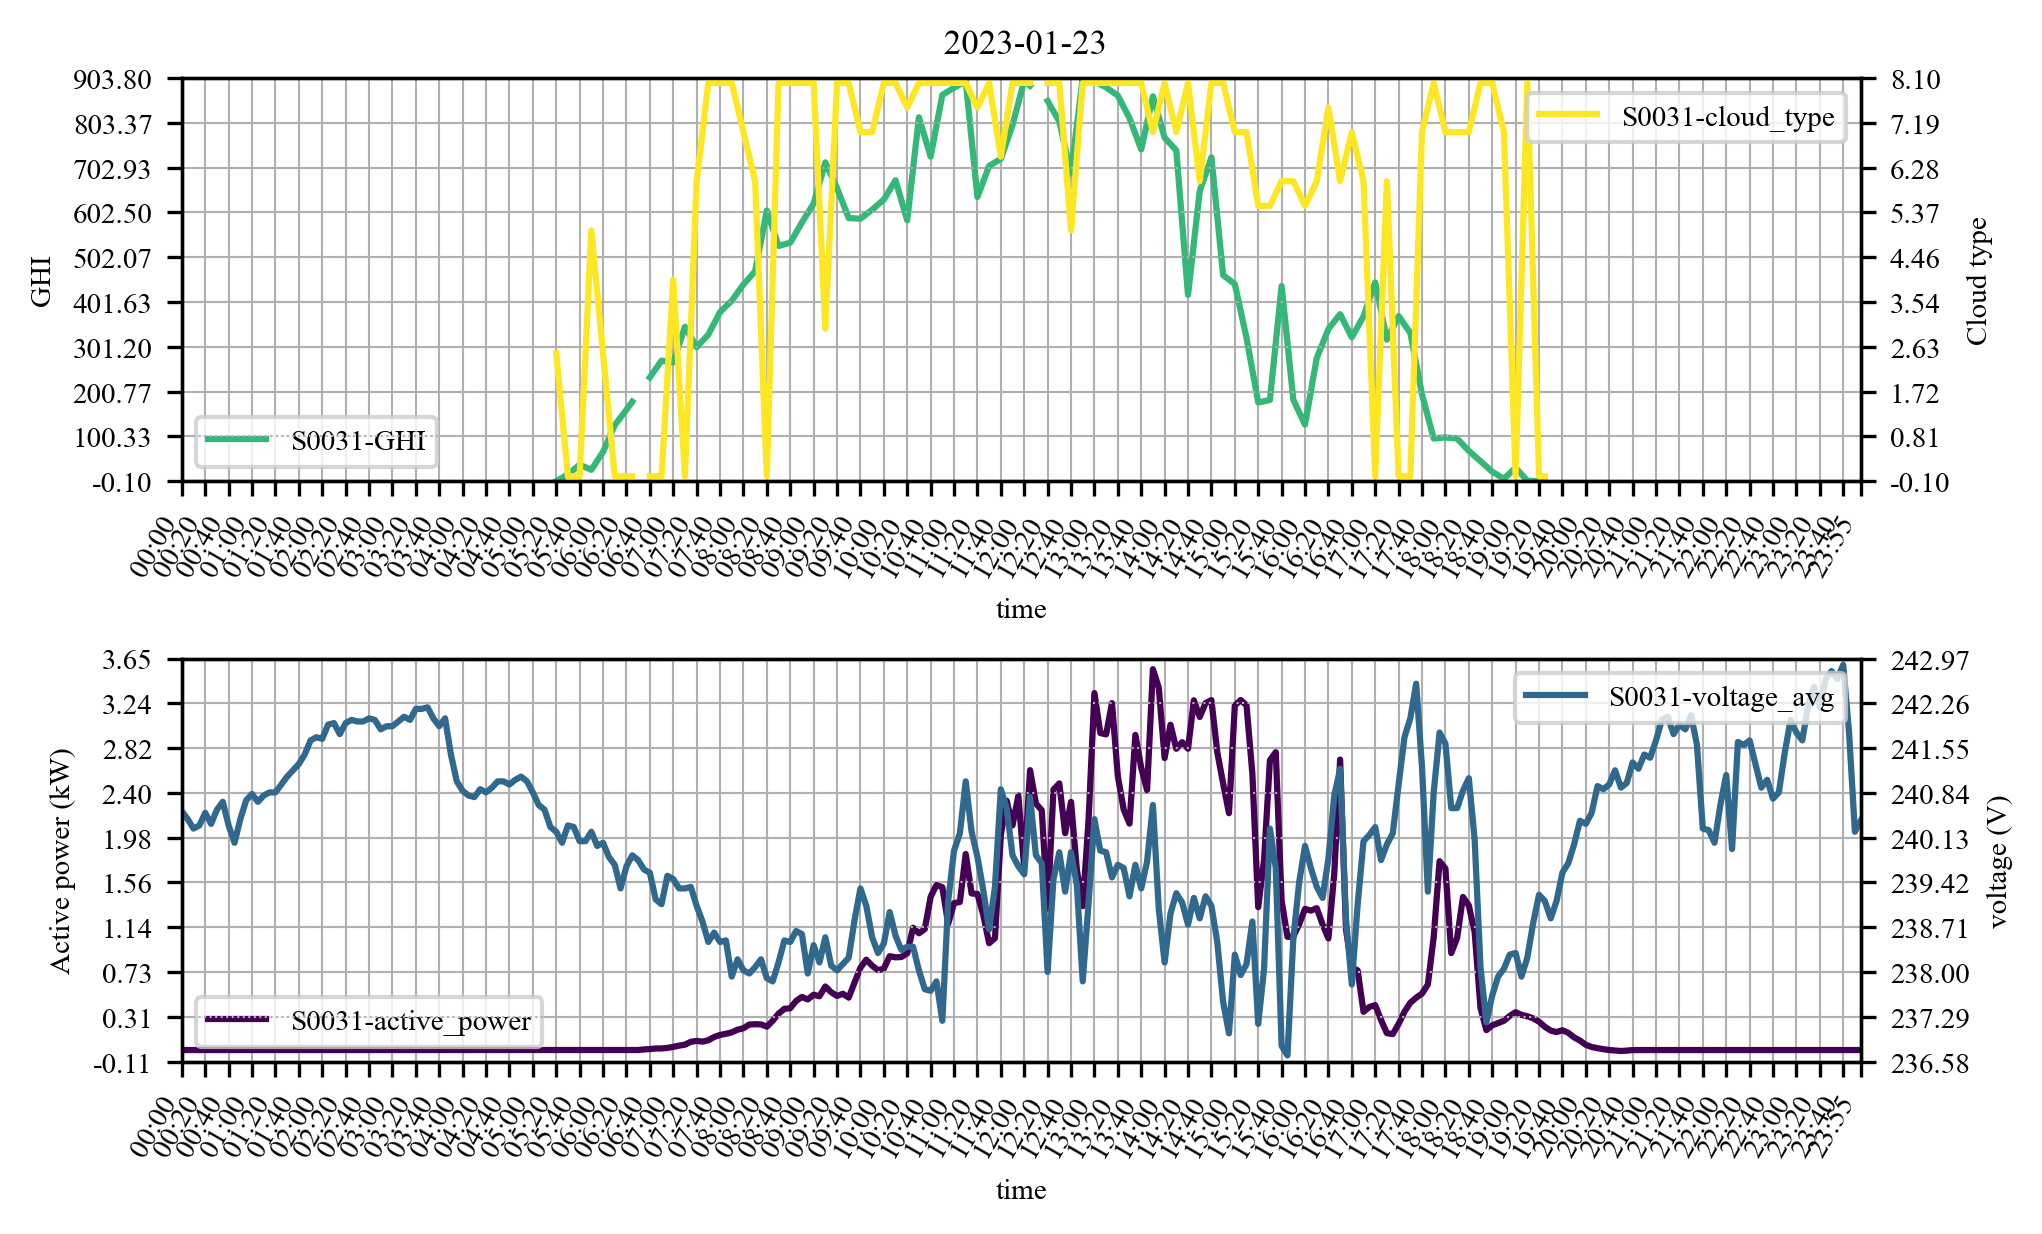

In [275]:
df1 = df5.copy()
df1 = df1.query(f"edp_site_id == 'S0235'").reset_index(drop=True)
offset = df1["time"].dt.strftime("%z").str[:][0]
df3 = df1.merge(solar, on=["time", "postcode"], how="left")
(
    df1["time"].min(),
    df1["time"].max(),
    offset,
    df1["active_power"].max(),
    df1["Srated"].max(),
)

(Timestamp('2023-01-01 00:00:00+0930', tz='pytz.FixedOffset(570)'),
 Timestamp('2023-12-31 23:55:00+0930', tz='pytz.FixedOffset(570)'),
 '+0930',
 np.float64(9.0382908),
 np.float64(20.0))

In [132]:
df1["real_power"].max()

np.float64(9.0382908)

In [130]:
cols = meta_data2.columns.tolist()
for col in cols:
    # print(meta_data.query("edp_site_id  in ('S0150', 'S0365', 'S0309', 'S0440')")[col])
    # data = meta_data.query("edp_site_id  in ('S0237')")[col]
    data = meta_data2.query("edp_site_id  in ('S0235')")[col]
    # data = meta_data.query("edp_site_id  in ('S0379')")[col]
    print(col, data.values[0])

edp_site_id S0235
postcode 5125
Prated 20.0


In [46]:
def get_Q(P, pf):
    S = P / pf
    Q = np.sqrt(S**2 - P**2)
    return Q


get_Q(0.6, 0.8)

np.float64(0.4499999999999999)

In [182]:
df3["postcode"].unique()

array([5158])

In [244]:
meta_data["inverter_model"].value_counts().head(10)

inverter_model
X1-5.0T               31
GW5000D-NS             4
Primo                  4
Primo 5.0-1            4
Solis-3K-2G            4
Solis-mini-3000-4G     3
X3-5.0-T               3
X1-4.2T                3
Evershine TL5000       3
X1-3.0T                2
Name: count, dtype: int64

In [72]:
df1.query(f"P_noncomp > 0 ").head(2)

,time,edp_site_id,postcode,Prated,real_energy,reactive_energy,current_avg,voltage_avg,real_power,reactive_power,apparent_power,P_threshold,P_noncomp
414,2023-01-02 10:30:00+09:30,S0186,5290,3.0,233.0483,3.9322,10.4845,254.3,2.796580,0.047186,2.796978,2.554286,0.242294
442,2023-01-02 12:50:00+09:30,S0186,5290,3.0,251.1653,4.4067,9.6560,252.4,3.013984,0.052880,3.014447,3.000000,0.013984


In [211]:
df1.query(f"Q_noncomp > 0 ").head(2)

,time,edp_site_id,postcode,Srated,real_energy,reactive_energy,current_avg,voltage_avg,active_power,reactive_power,apparent_power,P_threshold,P_noncomp,Q_min,Q_max,Q_max_noncomp,Q_min_noncomp,Q_noncomp,wrong_on_maxP
0,2023-01-01 00:00:00+09:30,S0463,5214,10.0,-0.0886,4.6272,0.2290,244.4,-0.001063,0.055526,0.055537,10.0,0.0,-10.0,-1.466667,1.522193,0.0,1.522193,False
1,2023-01-01 00:05:00+09:30,S0463,5214,10.0,-0.0856,4.4492,0.2255,241.2,-0.001027,0.053390,0.053400,10.0,0.0,-10.0,-0.400000,0.453390,0.0,0.453390,False


In [99]:
"2023-01-01 00:00:00" + offset  # In sydney local time

'2023-01-01 00:00:00+0930'

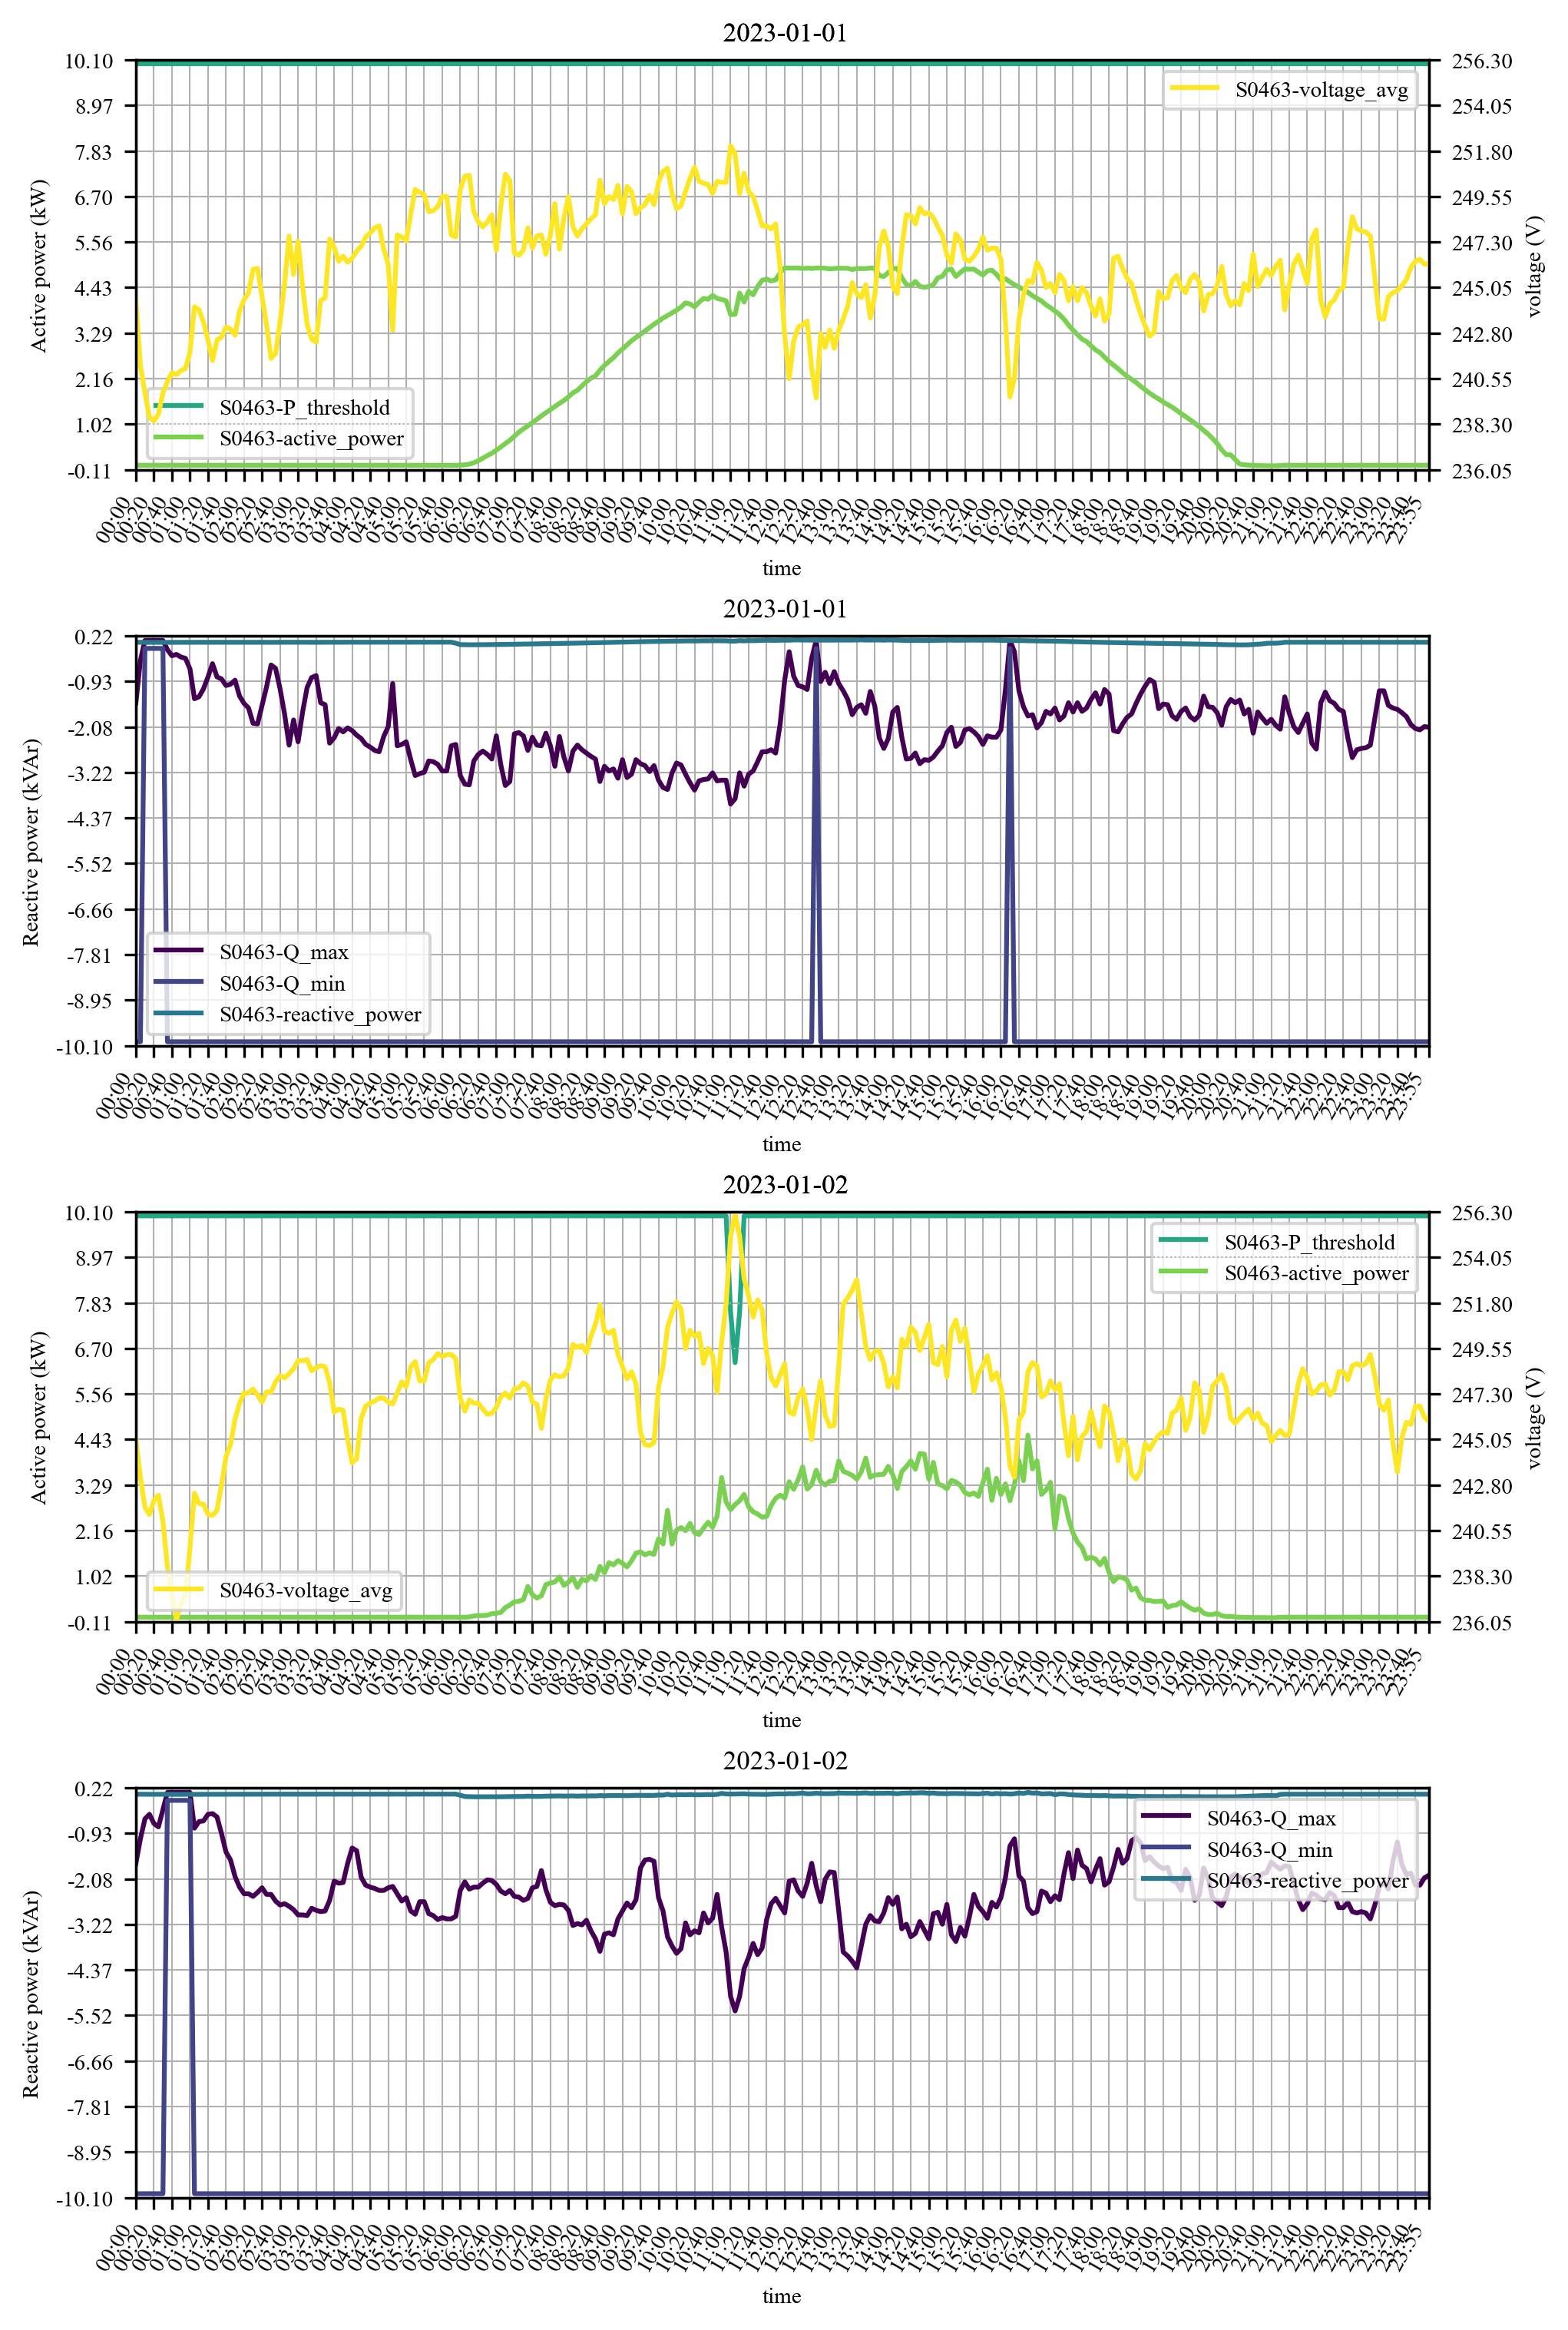

In [238]:
start_time = "2023-01-01 00:00:00" + offset  # In sydney local time
end_time = "2023-01-03 00:00:00" + offset  # In sydney local time

num_ticks = 73
save_as = ""
x_label = "time"
y_labels = [
    "Reactive power (kW)",
    "Reactive power (kW)",
    "Reactive power (kVAr)",
    "Active power (kW)",
    "Active power (kW)",
    "voltage (V)",
]
plt_config = {
    "Q_max": [1, 0, "-", None, None],
    "Q_min": [1, 0, "-", None, None],
    "reactive_power": [1, 0, "-", None, None],
    "P_threshold": [0, 0, "-", None, None],
    "active_power": [0, 0, "-", None, None],
    "voltage_avg": [0, 1, "-", None, None],
}
# y_labels = ['Active power (kW)',  'Apparent power (kVA)']
# plt_config = {'active_power': [0, 0, '-', -2.5, 4.5], 'apparent_power': [1, 1, '-', None, None]}
color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.2f"
a = my_plot4(
    start_time,
    end_time,
    df3,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="edp_site_id",
    time_attr="time",
    color_nights=color_nights,
    cmap="viridis",
    figsize=[17 / 2.54, 2.5],
    same_scale=1,
    fontsize=7,
    fontname="Times New Roman",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=300,
    x_format="%H:%M",
    legend_loc=["lower left", "upper right", "lower left", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.5, 0.5],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
)
a.do()

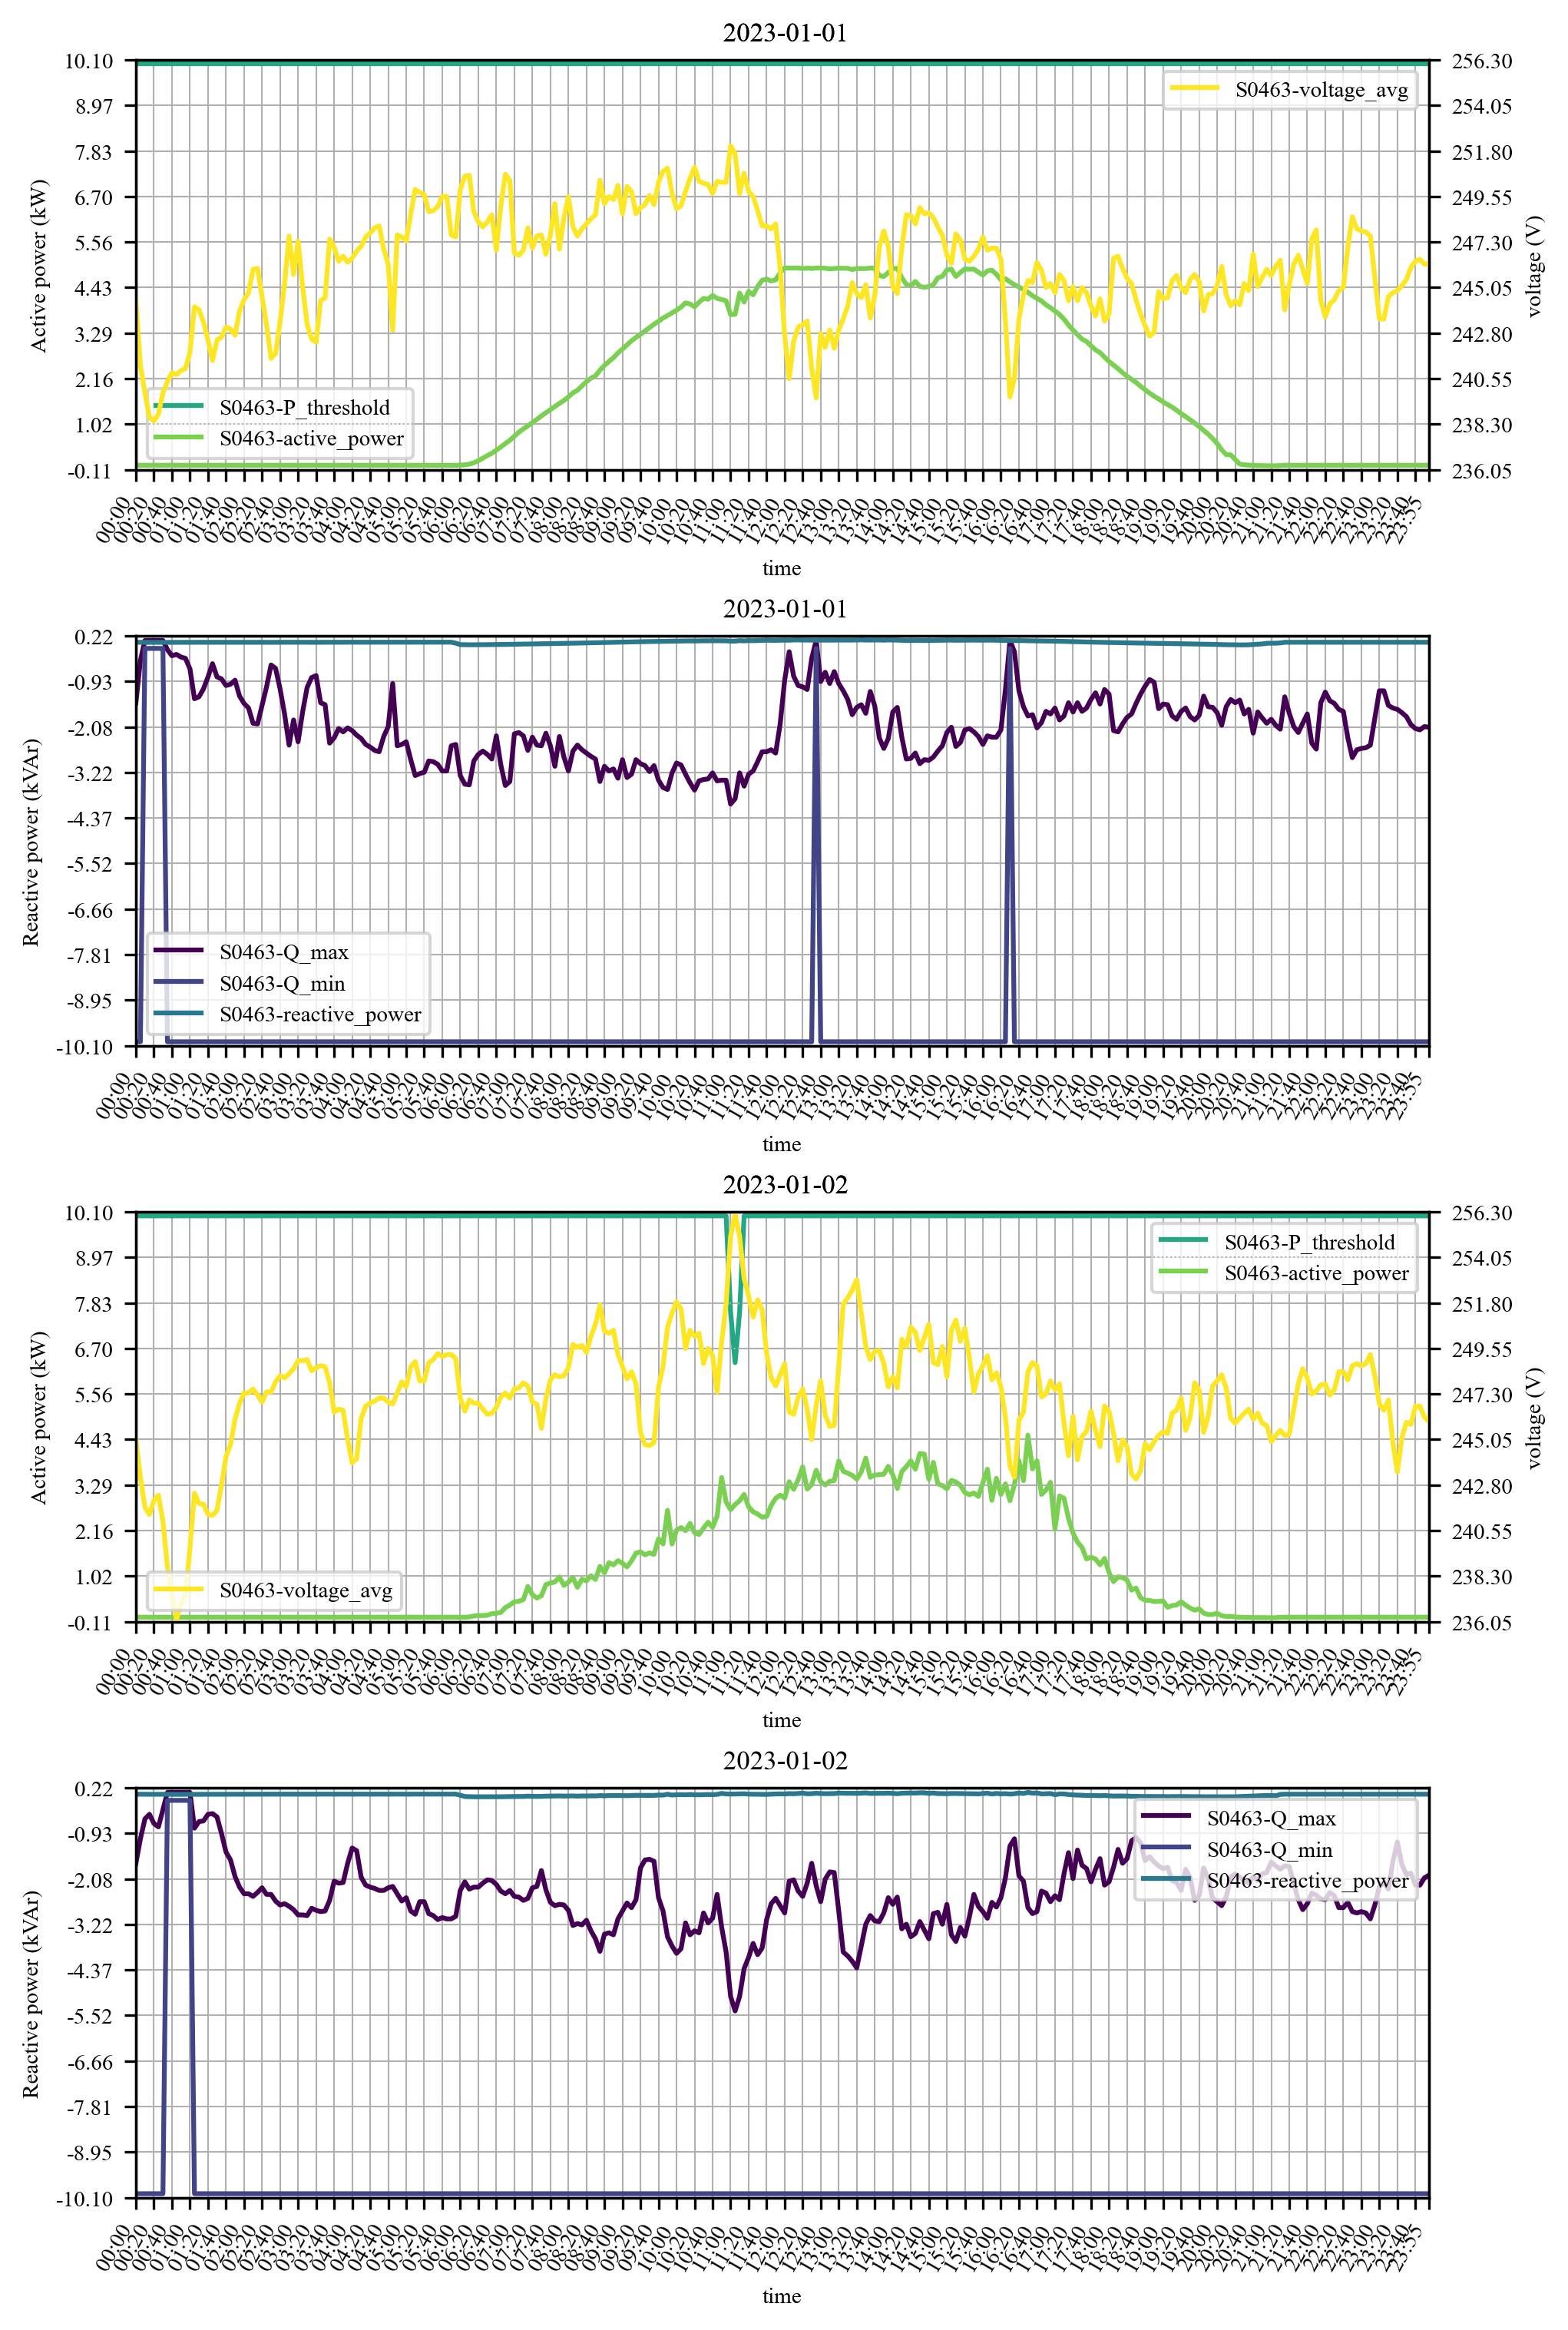

In [ ]:
start_time = "2023-01-01 00:00:00" + offset  # In sydney local time
end_time = "2023-01-03 00:00:00" + offset  # In sydney local time

num_ticks = 73
save_as = ""
x_label = "time"
y_labels = [
    "Reactive power (kW)",
    "Reactive power (kW)",
    "Reactive power (kVAr)",
    "Active power (kW)",
    "Active power (kW)",
    "voltage (V)",
]
plt_config = {
    "Q_max": [1, 0, "-", None, None],
    "Q_min": [1, 0, "-", None, None],
    "reactive_power": [1, 0, "-", None, None],
    "P_threshold": [0, 0, "-", None, None],
    "active_power": [0, 0, "-", None, None],
    "voltage_avg": [0, 1, "-", None, None],
}
# y_labels = ['Active power (kW)',  'Apparent power (kVA)']
# plt_config = {'active_power': [0, 0, '-', -2.5, 4.5], 'apparent_power': [1, 1, '-', None, None]}
color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.2f"
a = my_plot4(
    start_time,
    end_time,
    df3,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="edp_site_id",
    time_attr="time",
    color_nights=color_nights,
    cmap="viridis",
    figsize=[17 / 2.54, 2.5],
    same_scale=1,
    fontsize=7,
    fontname="Times New Roman",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=300,
    x_format="%H:%M",
    legend_loc=["lower left", "upper right", "lower left", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.5, 0.5],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
)
a.do()

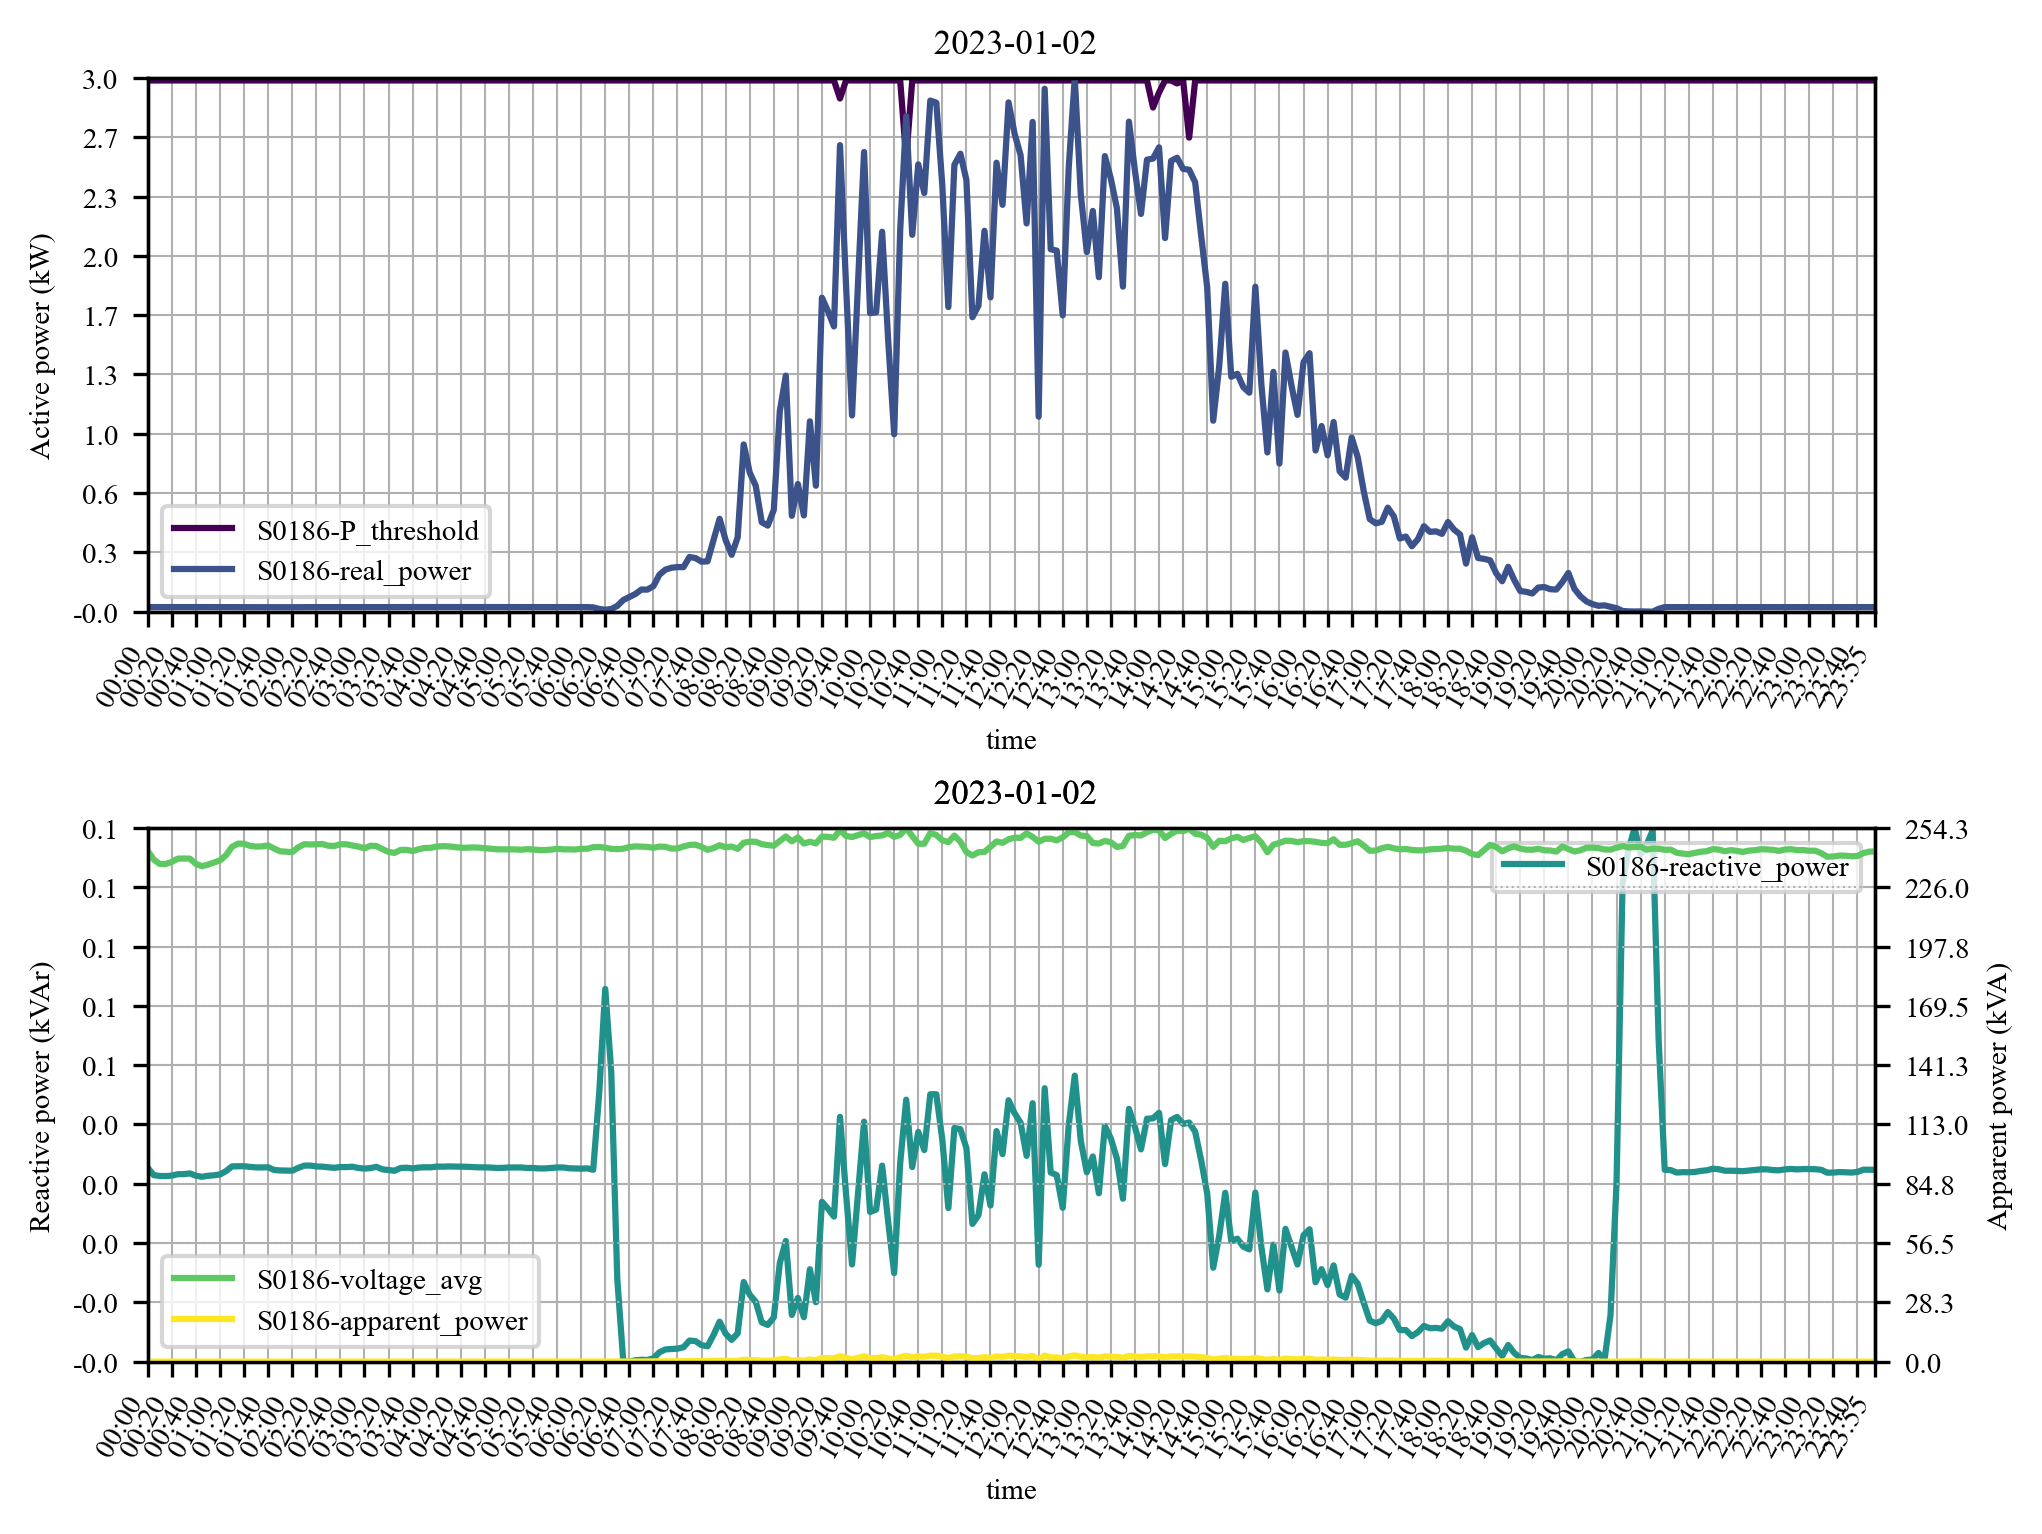

In [ ]:
start_time = "2023-01-02 00:00:00" + offset  # In sydney local time
end_time = "2023-01-03 00:00:00" + offset  # In sydney local time

num_ticks = 73
save_as = ""
x_label = "time"
y_labels = [
    "Active power (kW)",
    "Active power (kW)",
    "Reactive power (kVAr)",
    "voltage (V)",
    "Apparent power (kVA)",
]
plt_config = {
    "P_threshold": [0, 0, "-", None, None],
    "active_power": [0, 0, "-", None, None],
    "reactive_power": [1, 0, "-", None, None],
    "voltage_avg": [1, 1, "-", None, None],
    "apparent_power": [1, 1, "-", None, None],
}
# y_labels = ['Active power (kW)',  'Apparent power (kVA)']
# plt_config = {'active_power': [0, 0, '-', -2.5, 4.5]}
color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    df3,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="edp_site_id",
    time_attr="time",
    color_nights=color_nights,
    cmap="viridis",
    figsize=[17 / 2.54, 2.5],
    same_scale=1,
    fontsize=7,
    fontname="Times New Roman",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=300,
    x_format="%H:%M",
    legend_loc=["lower left", "upper right", "lower left", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.5, 0.5],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
)
a.do()

In [14]:
a.y_max

[5.0600000000000005, 5.0600000000000005, 0.4913232, 256.05, 4.184921931415496]

In [10]:
# start_time = '2023-01-01 00:00:00'+offset # In sydney local time
# end_time = '2023-01-02 00:00:00'+offset # In sydney local time

# num_ticks = 73
# save_as = ''
# x_label = 'time'
# y_labels = ['Active power (kW)', 'Active power (kW)', 'Reactive power (kVAr)', 'voltage (V)', 'Apparent power (kVA)']
# plt_config = {'P_threshold': [0, 0, '-', None, None], 'real_power': [0, 0, '-', None, None],'reactive_power': [1, 0, '-', None, None],
# 'voltage_avg': [0, 1, '-', None, None], 'apparent_power': [1, 1, '-', None, None]}
# # y_labels = ['Active power (kW)',  'Apparent power (kVA)']
# # plt_config = {'real_power': [0, 0, '-', -2.5, 4.5]}
# color_nights=False
# # color_by = 'group'
# color_by = 'attribute'
# ax_digit = '1.1f'
# a=my_plot4(start_time, end_time, df3, plt_config=plt_config, ax_digit= ax_digit,
#           group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='viridis',
#           figsize=[17/2.54,2.5],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']],
#           num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M',
#            legend_loc=['lower left', 'upper right', 'lower left', 'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
# plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.5, .5], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
# a.do()

In [11]:
# start_time = '2023-01-01 00:00:00'+offset # In sydney local time
# end_time = '2023-01-02 00:00:00'+offset # In sydney local time

# num_ticks = 73
# save_as = ''
# x_label = 'time'
# y_labels = ['Active power (kW)', 'Active power (kW)', 'Reactive power (kVAr)', 'voltage (V)', 'Apparent power (kVA)']
# plt_config = {'P_threshold': [0, 0, '-', None, None], 'real_power': [0, 0, '-', None, None],'reactive_power': [1, 0, '-', None, None],
# 'voltage_avg': [0, 1, '-', None, None], 'apparent_power': [1, 1, '-', None, None]}
# # y_labels = ['Active power (kW)',  'Apparent power (kVA)']
# # plt_config = {'real_power': [0, 0, '-', -2.5, 4.5]}
# color_nights=False
# # color_by = 'group'
# color_by = 'attribute'
# ax_digit = '1.1f'
# a=my_plot4(start_time, end_time, df3, plt_config=plt_config, ax_digit= ax_digit,
#           group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='viridis',
#           figsize=[17/2.54,2.5],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']],
#           num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M',
#            legend_loc=['lower left', 'upper right', 'lower left', 'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
# plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.5, .5], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
# a.do()

In [12]:
# start_time = '2023-03-01 00:00:00'+offset # In sydney local time
# end_time = '2023-03-02 00:00:00'+offset # In sydney local time

# num_ticks = 73
# save_as = ''
# x_label = 'time'
# y_labels = ['Active power (kW)', 'Active power (kW)', 'Reactive power (kVAr)', 'voltage (V)', 'Apparent power (kVA)']
# plt_config = {'P_threshold': [0, 0, '-', None, None], 'real_power': [0, 0, '-', None, None],'reactive_power': [1, 0, '-', None, None],
# 'voltage_avg': [0, 1, '-', None, None], 'apparent_power': [1, 1, '-', None, None]}
# # y_labels = ['Active power (kW)',  'Apparent power (kVA)']
# # plt_config = {'real_power': [0, 0, '-', -2.5, 4.5]}
# color_nights=False
# # color_by = 'group'
# color_by = 'attribute'
# ax_digit = '1.1f'
# a=my_plot4(start_time, end_time, df3, plt_config=plt_config, ax_digit= ax_digit,
#           group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='viridis',
#           figsize=[17/2.54,2.5],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']],
#           num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M',
#            legend_loc=['lower left', 'upper right', 'lower left', 'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
# plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.5, .5], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
# a.do()

In [190]:
df3["postcode"].unique()

array([5012])

In [28]:
df44 = (
    solar.query(f"postcode==5012")
    .sort_values(by="time")
    .reset_index(drop=True)[["time", "postcode", "surface_global_irradiance"]]
)

In [29]:
df11 = (
    df1.query(f"postcode==5012")
    .sort_values(by="time")
    .reset_index(drop=True)[["time", "postcode", "real_energy", "voltage_avg"]]
)

In [33]:
df11.merge(df44, on=["time", "postcode"], how="left")

,time,postcode,real_energy,voltage_avg,surface_global_irradiance
0,2023-01-01 00:00:00+10:00,5012,-0.6725,241.45,NaN
1,2023-01-01 00:00:00+10:00,5012,-0.0044,242.25,NaN
2,2023-01-01 00:00:00+10:00,5012,-0.0056,243.55,NaN
3,2023-01-01 00:05:00+10:00,5012,-0.0061,243.35,NaN
4,2023-01-01 00:05:00+10:00,5012,-0.6711,241.20,NaN
...,...,...,...,...,...
297676,2023-12-31 23:50:00+10:00,5012,-0.6731,241.65,NaN
297677,2023-12-31 23:50:00+10:00,5012,-0.0056,242.30,NaN
297678,2023-12-31 23:55:00+10:00,5012,-0.0053,244.00,NaN
297679,2023-12-31 23:55:00+10:00,5012,-0.6742,241.55,NaN


In [32]:
df44["postcode"][0]

np.int64(5012)

In [34]:
df3.query(f"postcode==5012")["surface_global_irradiance"]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
297676   NaN
297677   NaN
297678   NaN
297679   NaN
297680   NaN
Name: surface_global_irradiance, Length: 297681, dtype: float64

In [46]:
df3["surface_global_irradiance"] = df3["surface_global_irradiance"].fillna(0)

In [13]:
# start_time = '2023-01-01 00:00:00+10:00' # In sydney local time
# end_time = '2023-01-05 00:00:00+10:00' # In sydney local time

# num_ticks = 25
# save_as = ''
# x_label = 'time'
# y_labels = ['real_energy', 'voltage_avg', 'surface_global_irradiance']
# plt_config = {'real_energy': [0, 0, '-', None, None],
# 'voltage_avg': [0, 1, '-', None, None], 'surface_global_irradiance': [1, 0, '-', None, None]}
# special_legend = []
# color_nights=False
# kW2MW_attr = []
# ax_digit = '1.1f'
# a=my_plot4(start_time, end_time, df3, plt_config=plt_config, ax_digit= ax_digit,
#           group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='RdYlBu',
#           figsize=[17/2.54,2.],  same_scale=False, fontsize=9, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']],
#           E2P_attr=None, num_ticks=num_ticks, num_yticks=5, dpi=300, special_legend=special_legend, x_format= '%H:%M', MW=False,
#            legend_loc=['upper left', 'upper right'], x_label=x_label, y_labels=y_labels, kW2MW_attr=kW2MW_attr,
# plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 25, step=True, gridwidth=[0.5, .5], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
# a.do()